In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load your dataset
df = pd.read_csv('food_test.csv')

# Preview
df.head()

,"2 magere grillburgers, drie eetlepels rijst, 250 gr sperziebonen",1490214763
0,Ongeveer 350 ml bier en een glas water,1490201118
1,40 gr muesli 200gr magere yoghurt beker thee g...,1490195805
2,1 bruine boterham pindakaas en 2 koffie,1490143624
3,250 ml melk met twee schepjes maaltijdshake,1490180208
4,1 x latte machiato,1490172382


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column                                                            Non-Null Count  Dtype
---  ------                                                            --------------  -----
 0   2 magere grillburgers, drie eetlepels rijst, 250 gr sperziebonen  6 non-null      str  
 1   1490214763                                                        6 non-null      int64
dtypes: int64(1), str(1)
memory usage: 431.0 bytes


2 magere grillburgers, drie eetlepels rijst, 250 gr sperziebonen    0
1490214763                                                          0
dtype: int64

In [5]:
for col in df.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [7]:
if 'target' in df.columns:
    X = df.drop('target', axis=1)
    y = df['target']
else:
    print("Column 'target' not found. Available columns:", df.columns)

Column 'target' not found. Available columns: Index(['2 magere grillburgers, drie eetlepels rijst, 250 gr sperziebonen', '1490214763'], dtype='str')


In [11]:
print(df.head())
print(df.columns)

   2 magere grillburgers, drie eetlepels rijst, 250 gr sperziebonen  1490214763
0                                                  5                 1490201118
1                                                  4                 1490195805
2                                                  0                 1490143624
3                                                  2                 1490180208
4                                                  1                 1490172382
Index(['2 magere grillburgers, drie eetlepels rijst, 250 gr sperziebonen', '1490214763'], dtype='str')


In [14]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = load_iris()
X = data.data      # features
y = data.target    # labels

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



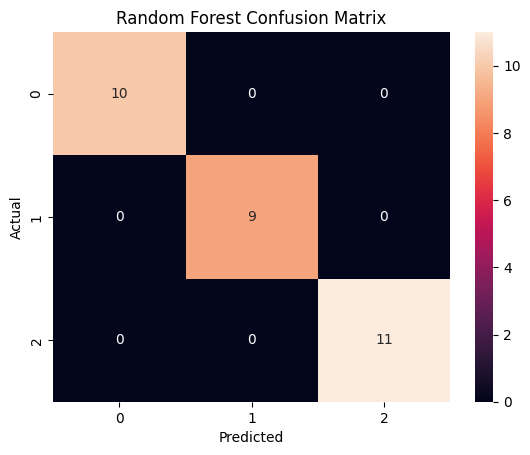

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train model (if not already done)
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Create predictions
y_pred_rf = rf_model.predict(X_test)

# Plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

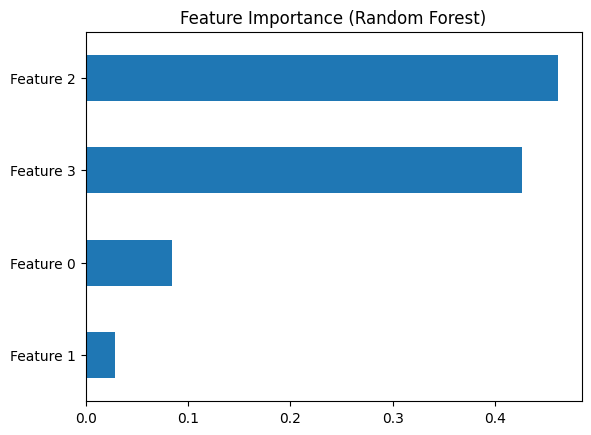

In [18]:
importances = rf_model.feature_importances_

feature_names = [f"Feature {i}" for i in range(X.shape[1])]

forest_importance = pd.Series(importances, index=feature_names)

forest_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()